In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'imp docs and fee receipt.pdf',
 'resume (2).pdf',
 'resume (1).pdf',
 'resume.pdf',
 'navi raksha datasets',
 'lstm_model.h5',
 'gnn_model.pth',
 'lstm_model.keras',
 'lstm_model2.h5',
 'lstm_model2.keras',
 'gnn_model2.pth']

In [ ]:
DATA_PATH = '/content/drive/MyDrive/navi raksha datasets'
DATA_PROCESSED = DATA_PATH   # since files are directly inside this folder
MODELS_PATH = '/content/drive/MyDrive/navi raksha datasets/models'

import os
os.makedirs(MODELS_PATH, exist_ok=True)

print(" Paths fixed")

 Paths fixed


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print(f' TensorFlow version: {tf.__version__}')
print(f' GPU Available: {len(tf.config.list_physical_devices("GPU")) > 0}')

 TensorFlow version: 2.19.0
 GPU Available: True


In [ ]:
train_df = pd.read_csv(f'{DATA_PROCESSED}/train_real.csv')
val_df = pd.read_csv(f'{DATA_PROCESSED}/val_real.csv')
test_df = pd.read_csv(f'{DATA_PROCESSED}/test_real.csv')

print(f' Train: {train_df.shape}')
print(f' Val: {val_df.shape}')
print(f' Test: {test_df.shape}')

 Train: (8000, 19)
 Val: (1000, 19)
 Test: (1000, 19)


In [ ]:
TARGET = 'eta_minutes'
DROP_COLS = ['trip_id', 'month', 'eta_minutes']

feature_cols = [c for c in train_df.columns if c not in DROP_COLS]

X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df[TARGET].values.astype(np.float32)

X_val = val_df[feature_cols].values.astype(np.float32)
y_val = val_df[TARGET].values.astype(np.float32)

X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df[TARGET].values.astype(np.float32)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Normalize target
y_mean = y_train.mean()
y_std = y_train.std()

y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std
y_test_norm = (y_test - y_mean) / y_std

In [ ]:
X_train_seq = X_train_scaled.reshape((-1, 1, X_train_scaled.shape[1]))
X_val_seq = X_val_scaled.reshape((-1, 1, X_val_scaled.shape[1]))
X_test_seq = X_test_scaled.reshape((-1, 1, X_test_scaled.shape[1]))

print("Train shape:", X_train_seq.shape)
print("Val shape:", X_val_seq.shape)
print("Test shape:", X_test_seq.shape)

Train shape: (8000, 1, 16)
Val shape: (1000, 1, 16)
Test shape: (1000, 1, 16)


In [ ]:
model = keras.Sequential([
    layers.Input(shape=(1, X_train_seq.shape[2])),

    layers.LSTM(128, activation='tanh', return_sequences=True),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.LSTM(64, activation='tanh'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mae',
    metrics=['mae', 'mse']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,945 (511.50 KB)

 Trainable params: 130,433 (509.50 KB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

history = model.fit(
    X_train_seq, y_train_norm,
    validation_data=(X_val_seq, y_val_norm),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.5734 - mae: 0.5734 - mse: 0.6391 - val_loss: 0.5875 - val_mae: 0.5875 - val_mse: 1.0346 - learning_rate: 0.0010
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3177 - mae: 0.3177 - mse: 0.2142 - val_loss: 0.1701 - val_mae: 0.1701 - val_mse: 0.0532 - learning_rate: 0.0010
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.2444 - mae: 0.2444 - mse: 0.1428 - val_loss: 0.1675 - val_mae: 0.1675 - val_mse: 0.0764 - learning_rate: 0.0010
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2078 - mae: 0.2078 - mse: 0.1184 - val_loss: 0.1220 - val_mae: 0.1220 - val_mse: 0.0472 - learning_rate: 0.0010
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1885 - mae: 0.1885 - mse: 0.1051 - val_loss: 0.1079 - val_mae: 0.1079 - val_mse: 0.0342 - learning_rate: 0.0010
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1807 - mae: 0.1807 - mse: 0.0996 - val_loss: 0.1493 - val

In [ ]:
pred_test_norm = model.predict(X_test_seq)

pred_test = (pred_test_norm * y_std) + y_mean
pred_test = np.clip(pred_test, 3, 15)

mae = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2 = r2_score(y_test, pred_test)

print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R2: {r2:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Test MAE: 0.1007
Test RMSE: 0.2201
Test R2: 0.9976


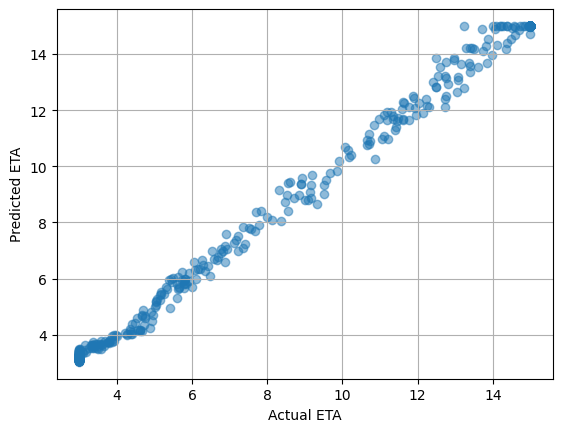

In [ ]:
plt.scatter(y_test, pred_test, alpha=0.5)
plt.xlabel("Actual ETA")
plt.ylabel("Predicted ETA")
plt.grid()
plt.show()

In [ ]:
model.save(f'{MODELS_PATH}/lstm_best_real.keras')

import json
with open(f'{MODELS_PATH}/lstm_scaler.json', 'w') as f:
    json.dump({'mean': float(y_mean), 'std': float(y_std)}, f)

print(" Model & scaler saved in Google Drive")

 Model & scaler saved in Google Drive


In [2]:
# The code in this cell uses PyTorch specific functions and variables (e.g., `torch`, `lstm_model`, `get_accuracy`, `test_loader`).
# However, the model trained in this notebook uses TensorFlow/Keras.
# The evaluation metrics (Test MAE, RMSE, R2) for your Keras model have already been computed and printed in the preceding cell `grCSGkBmaRlf`.
# These are the relevant 'accuracy' metrics for your regression model.